In [0]:
# Gold Layer — SQL Analysis
# =========================
# Run this notebook in Databricks against the gold star schema.
# Produces 5 analyses suitable for README screenshots.
#
# Prerequisites: gold tables registered in road_pipeline database
# (run gold_layer_databricks notebook first)

# ── Setup ────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

spark.sql("USE road_pipeline")

spark.sql("SHOW TABLES IN road_pipeline").show()

+-------------+--------------------+-----------+
|     database|           tableName|isTemporary|
+-------------+--------------------+-----------+
|road_pipeline|        dim_location|      false|
|road_pipeline|    dim_road_segment|      false|
|road_pipeline|            dim_time|      false|
|road_pipeline| fact_traffic_counts|      false|
|road_pipeline|road_segments_silver|      false|
|road_pipeline|   tms_counts_silver|      false|
|road_pipeline|tms_monitoring_si...|      false|
+-------------+--------------------+-----------+



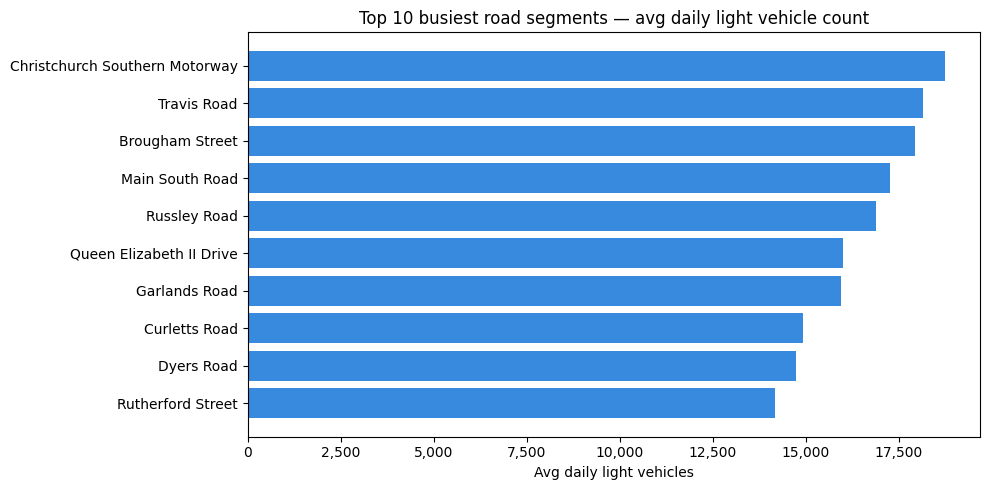

                          name road_class  avg_daily_vehicles
Christchurch Southern Motorway   motorway             18741.0
                   Travis Road   arterial             18142.0
               Brougham Street   arterial             17943.0
               Main South Road   arterial             17265.0
                  Russley Road   arterial             16890.0
      Queen Elizabeth II Drive   arterial             15994.0
                 Garlands Road   arterial             15932.0
                 Curletts Road   arterial             14916.0
                    Dyers Road   arterial             14736.0
             Rutherford Street   arterial             14175.0


In [0]:
# ── 1. Top 10 busiest road segments by average daily traffic ─────────────────
busy_roads = spark.sql("""
    SELECT
        s.name,
        s.road_class,
        ROUND(AVG(f.daily_count), 0) AS avg_daily_vehicles
    FROM fact_traffic_counts f
    JOIN dim_location       l ON f.site_id    = l.site_id
    JOIN dim_road_segment   s ON f.segment_id = s.segment_id
    JOIN dim_time           t ON f.date_id    = t.date_id
    WHERE f.vehicle_class = 'Light'
      AND s.name IS NOT NULL
    GROUP BY s.name, s.road_class
    ORDER BY avg_daily_vehicles DESC
    LIMIT 10
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(busy_roads["name"], busy_roads["avg_daily_vehicles"],
               color="#378ADD")
ax.set_xlabel("Avg daily light vehicles")
ax.set_title("Top 10 busiest road segments — avg daily light vehicle count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/tmp/01_busiest_roads.png", dpi=150)
plt.show()
print(busy_roads.to_string(index=False))



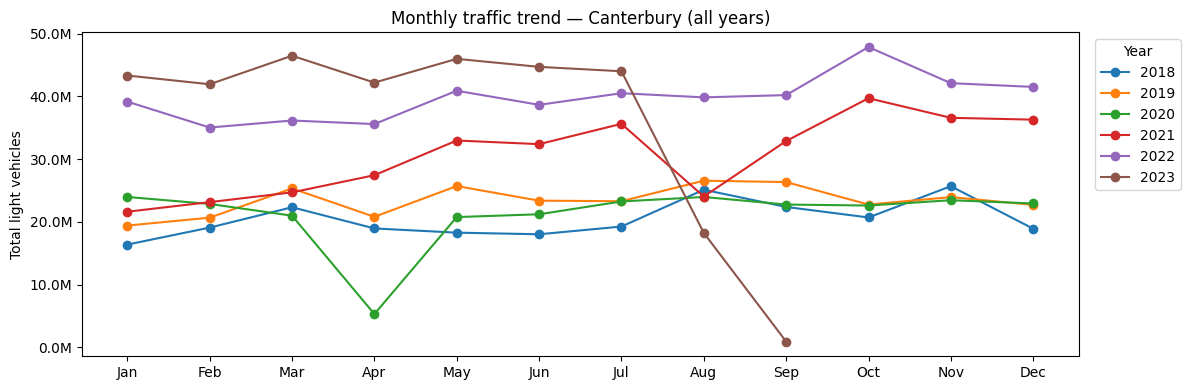

In [0]:
# ── 2. Monthly traffic trend (Canterbury, all years) ─────────────────────────
monthly = spark.sql("""
    SELECT
        t.year,
        t.month,
        t.month_name,
        SUM(f.daily_count) AS total_vehicles
    FROM fact_traffic_counts f
    JOIN dim_time t ON f.date_id = t.date_id
    WHERE f.vehicle_class = 'Light'
    GROUP BY t.year, t.month, t.month_name
    ORDER BY t.year, t.month
""").toPandas()

fig, ax = plt.subplots(figsize=(12, 4))
for yr, grp in monthly.groupby("year"):
    ax.plot(grp["month"], grp["total_vehicles"], marker="o",
            label=str(yr), linewidth=1.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x/1e6):.1f}M"))
ax.set_ylabel("Total light vehicles")
ax.set_title("Monthly traffic trend — Canterbury (all years)")
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/tmp/02_monthly_trend.png", dpi=150)
plt.show()



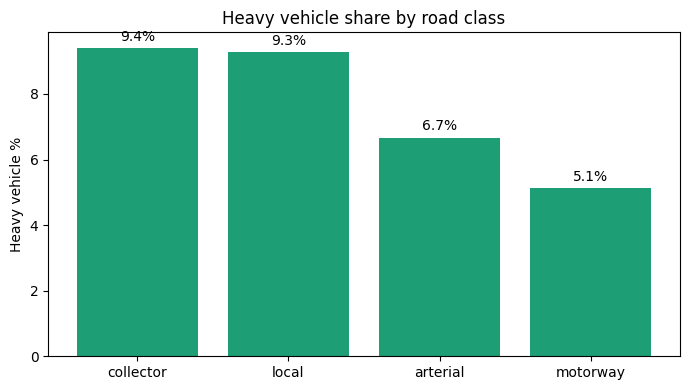

road_class heavy_pct
 collector      9.41
     local      9.29
  arterial      6.67
  motorway      5.12


In [0]:
# ── 3. Heavy vehicle % by road class ─────────────────────────────────────────
heavy_pct = spark.sql("""
    SELECT
        s.road_class,
        ROUND(
            100.0 * SUM(CASE WHEN f.vehicle_class = 'Heavy' THEN f.daily_count ELSE 0 END)
                  / SUM(f.daily_count), 2
        ) AS heavy_pct
    FROM fact_traffic_counts f
    JOIN dim_location     l ON f.site_id    = l.site_id
    JOIN dim_road_segment s ON f.segment_id = s.segment_id
    WHERE f.daily_count > 0
    GROUP BY s.road_class
    ORDER BY heavy_pct DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(heavy_pct["road_class"], heavy_pct["heavy_pct"],
              color="#1D9E75")
ax.set_ylabel("Heavy vehicle %")
ax.set_title("Heavy vehicle share by road class")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.savefig("/tmp/03_heavy_vehicle_pct.png", dpi=150)
plt.show()
print(heavy_pct.to_string(index=False))



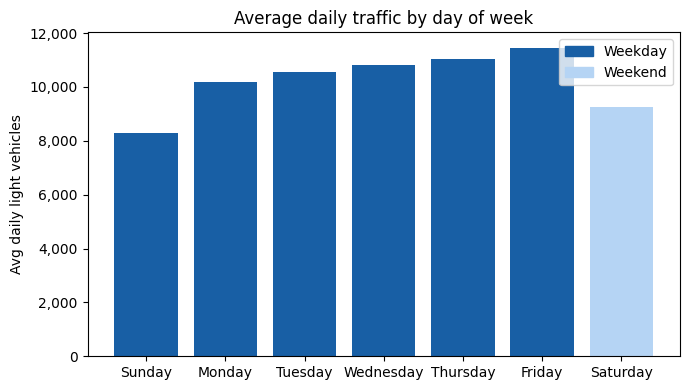

 day_name  avg_daily_vehicles
   Sunday              8295.0
   Monday             10172.0
  Tuesday             10567.0
Wednesday             10828.0
 Thursday             11054.0
   Friday             11453.0
 Saturday              9241.0


In [0]:
# ── 4. Weekday vs weekend traffic ─────────────────────────────────────────────
dow = spark.sql("""
    SELECT
        t.day_name,
        t.day_of_week,
        ROUND(AVG(f.daily_count), 0) AS avg_daily_vehicles
    FROM fact_traffic_counts f
    JOIN dim_time t ON f.date_id = t.date_id
    WHERE f.vehicle_class = 'Light'
    GROUP BY t.day_name, t.day_of_week
    ORDER BY t.day_of_week
""").toPandas()

weekend_color = ["#B5D4F4" if d in (5, 6) else "#185FA5"
                 for d in dow["day_of_week"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dow["day_name"], dow["avg_daily_vehicles"],
              color=weekend_color)
ax.set_ylabel("Avg daily light vehicles")
ax.set_title("Average daily traffic by day of week")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#185FA5", label="Weekday"),
    Patch(color="#B5D4F4", label="Weekend"),
])
plt.tight_layout()
plt.savefig("/tmp/04_dow_traffic.png", dpi=150)
plt.show()
print(dow[["day_name", "avg_daily_vehicles"]].to_string(index=False))



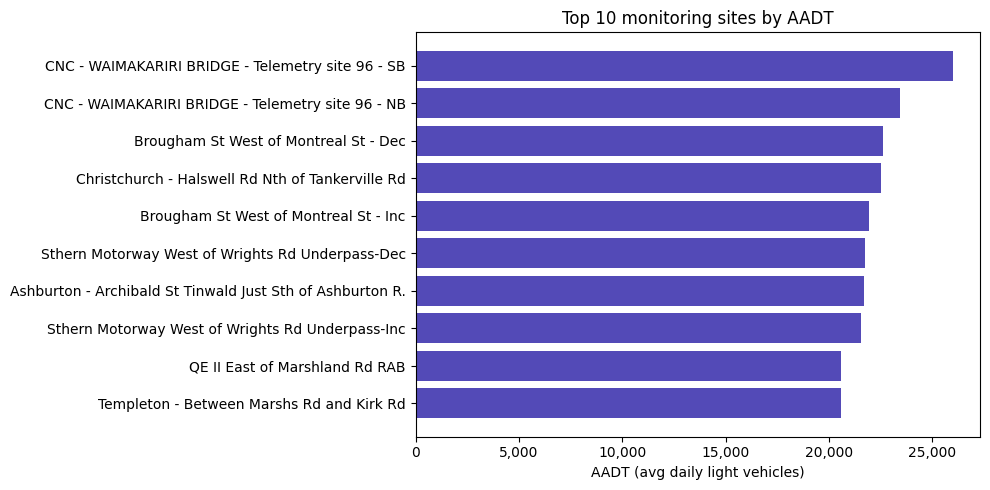

                                         site_description          region    aadt
        CNC - WAIMAKARIRI BRIDGE - Telemetry site 96 - SB 11 - Canterbury 26003.0
        CNC - WAIMAKARIRI BRIDGE - Telemetry site 96 - NB 11 - Canterbury 23413.0
                    Brougham St West of Montreal St - Dec 11 - Canterbury 22610.0
         Christchurch - Halswell Rd Nth of Tankerville Rd 11 - Canterbury 22495.0
                    Brougham St West of Montreal St - Inc 11 - Canterbury 21919.0
         Sthern Motorway West of Wrights Rd Underpass-Dec 11 - Canterbury 21759.0
Ashburton - Archibald St Tinwald Just Sth of Ashburton R. 11 - Canterbury 21671.0
         Sthern Motorway West of Wrights Rd Underpass-Inc 11 - Canterbury 21544.0
                           QE II East of Marshland Rd RAB 11 - Canterbury 20570.0
                Templeton - Between Marshs Rd and Kirk Rd 11 - Canterbury 20560.0

All charts saved to /tmp/ — download and add to README screenshots.


In [0]:
# ── 5. Top 10 sites by AADT (annual average daily traffic) ───────────────────
aadt = spark.sql("""
    SELECT
        l.site_description,
        l.region,
        ROUND(AVG(f.daily_count), 0) AS aadt
    FROM fact_traffic_counts f
    JOIN dim_location l ON f.site_id = l.site_id
    JOIN dim_time     t ON f.date_id = t.date_id
    WHERE f.vehicle_class = 'Light'
    GROUP BY l.site_description, l.region
    ORDER BY aadt DESC
    LIMIT 10
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(aadt["site_description"], aadt["aadt"], color="#534AB7")
ax.set_xlabel("AADT (avg daily light vehicles)")
ax.set_title("Top 10 monitoring sites by AADT")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/tmp/05_top_sites_aadt.png", dpi=150)
plt.show()
print(aadt.to_string(index=False))

print("\nAll charts saved to /tmp/ — download and add to README screenshots.")
